# Week 01 (Module 12) — BBO capstone driver

I've been given **8 mystery functions**. Each one takes a few numbers between 0 and 1 and
spits back a single score. I can't see the formula inside — I only see the score it gives
for inputs I've tried. The goal is to find inputs that make the score as **big** as possible,
using as few tries as I can.

**The recipe each round, for every function:**
1. Take the input/output pairs I've collected so far.
2. Fit a **Gaussian Process** to them — a flexible model that guesses the score everywhere
   in the search box, *and* says how unsure it is at each point.
3. Use an **acquisition function** (a scoring rule for candidate inputs) to pick the single
   most useful input to query next.

I built **three modes** and pick one per function, depending on what stage that function is at:
- **Explore** — UCB with a high β: deliberately chase the most uncertain spots, to map the box.
- **Balanced** — Expected Improvement (EI): trade off "might score high" against "I'm unsure".
- **Optimise** — Probability of Improvement (PI): squeeze tightly around the current winner.

**This round (explore-first):** seven functions run in **Explore** mode, because I'm still
learning what each surface looks like. The exception is **f4**, where the model already thinks
an interior point would beat my best by a wide margin — so f4 runs **Balanced (EI)** to cash that in.

**Workflow each week:** run this notebook → copy the 8 submission strings into the portal →
write the reflection. When the portal returns the scores, paste them in at the bottom,
bump `WEEK`, and re-run next module.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
# Walk up the folder tree until we find bo.py, then make that the working directory.
# Lets me run this notebook from anywhere without breaking the imports.
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

# --- settings for this week ---
WEEK = 1
KIND = "matern"   # which model to fit: "matern" (smarter, tunes itself) or "rbf" (simpler fallback)
SEED = 0          # fixes the random parts so the same run gives the same proposals

# The three modes. Each is just a scoring rule plus its tuning knob.
EXPLORE  = dict(acq="ucb", beta=3.0)   # chase uncertainty — map the box
BALANCED = dict(acq="ei",  xi=0.01)    # trade "might be high" against "I'm unsure"
OPTIMISE = dict(acq="pi",  xi=0.0)     # greedy — squeeze around the current best

# This week's plan: every function explores, except f4 which exploits.
PLAN = {fid: dict(EXPLORE) for fid in bo.FUNC_IDS}
PLAN[4] = dict(BALANCED)

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)
pd.DataFrame([dict(func=f"f{fid}", **PLAN[fid]) for fid in bo.FUNC_IDS])


,func,acq,beta,xi
0,f1,ucb,3.0,NaN
1,f2,ucb,3.0,NaN
2,f3,ucb,3.0,NaN
3,f4,ei,NaN,0.01
4,f5,ucb,3.0,NaN
5,f6,ucb,3.0,NaN
6,f7,ucb,3.0,NaN
7,f8,ucb,3.0,NaN


## 1. Data — set up the working CSVs and look at what each function is

First time only: copy the starter input/output pairs into editable CSVs (one per function),
and print the portal's short description of each function so the strategy below makes sense.


In [2]:
bo.seed_csvs()          # makes data/f1..f8.csv from initial_data/*.npy (skips files that already exist)
bo.write_descriptions() # one-row-per-function summary table on disk
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]


,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Train the model and pick the next input for each function

For each of the 8 functions: train a Gaussian Process on its known points, score candidate
inputs with that function's chosen rule, and pick the highest-scoring point.
The table below shows what the model thinks about the chosen point: its best **guess**,
its **uncertainty**, and the **submission string** ready for the portal.


In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary

,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,10,0.0000,-0.0003,0.0011,ucb,0.666422-0.206532
1,f2,2,10,0.6112,0.3234,0.2222,ucb,0.983504-0.888870
2,f3,3,15,-0.0348,-0.0528,0.0839,ucb,0.000000-0.000000-0.000000
3,f4,4,30,-4.0255,-1.7845,0.7131,ei,0.440427-0.425455-0.378357-0.397087
4,f5,4,20,1088.8596,1639.0147,171.6268,ucb,0.000000-0.000000-0.999999-0.999999
5,f6,5,20,-0.7143,-0.3241,0.4270,ucb,0.268673-0.000000-0.520553-0.999999-0.000000
6,f7,6,30,1.3650,1.1519,0.1934,ucb,0.000000-0.390218-0.982287-0.196815-0.361745-0...
7,f8,8,40,9.5985,10.1344,0.3053,ucb,0.000000-0.000000-0.000000-0.000000-0.999999-0...


### What every scoring rule says about each chosen point

All four standard rules are evaluated at each proposed input — not just the one that picked it.
Useful for the reflection: if my chosen rule says "go here" but EI says "nothing to gain",
that's a sign the point is a probe, not an exploitation move.


In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0030,0.0000,0.0000
1,f2,0.0093,0.9900,0.0900,0.0494
2,f3,0.0213,0.1989,0.3694,0.0070
3,f4,2.2312,-0.3583,0.9991,0.5085
4,f5,550.1763,2153.8951,0.9993,29455.7597
5,f6,0.4239,0.9571,0.8134,0.1824
6,f7,0.0119,1.7322,0.1244,0.0374
7,f8,0.5312,11.0504,0.9575,0.0932


## 3. Plots

- **2D functions** (f1, f2): six heatmaps each — model guess, uncertainty, and each scoring
  rule across the whole box. Easy to eyeball where it's chasing and why.
- **Higher-D functions**: one panel per input axis, slicing through the current best point.
  Shows the guess (line), uncertainty band, and where the next query falls on each axis.
- **Diagnostics** (every function): "best score so far" curve, and a leave-one-out plot
  (how well does the model predict each known point if I hide it). Diagonal cloud = healthy.


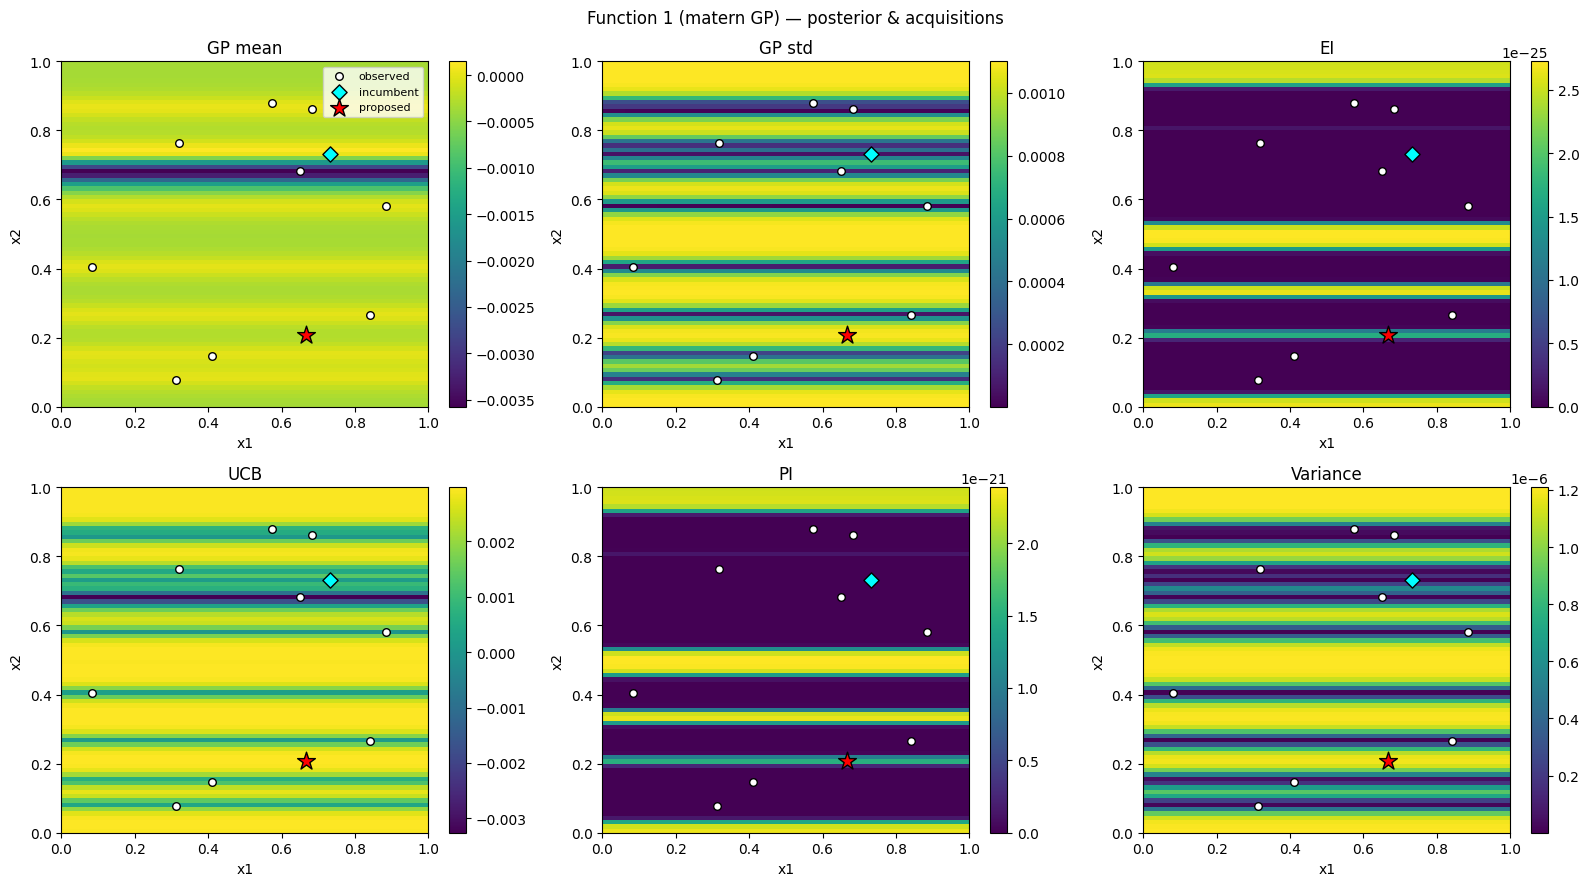

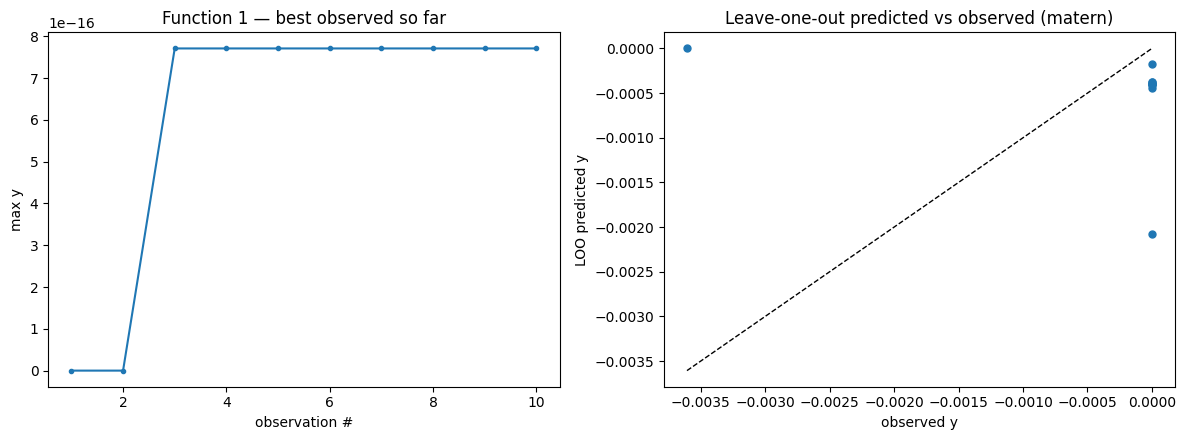

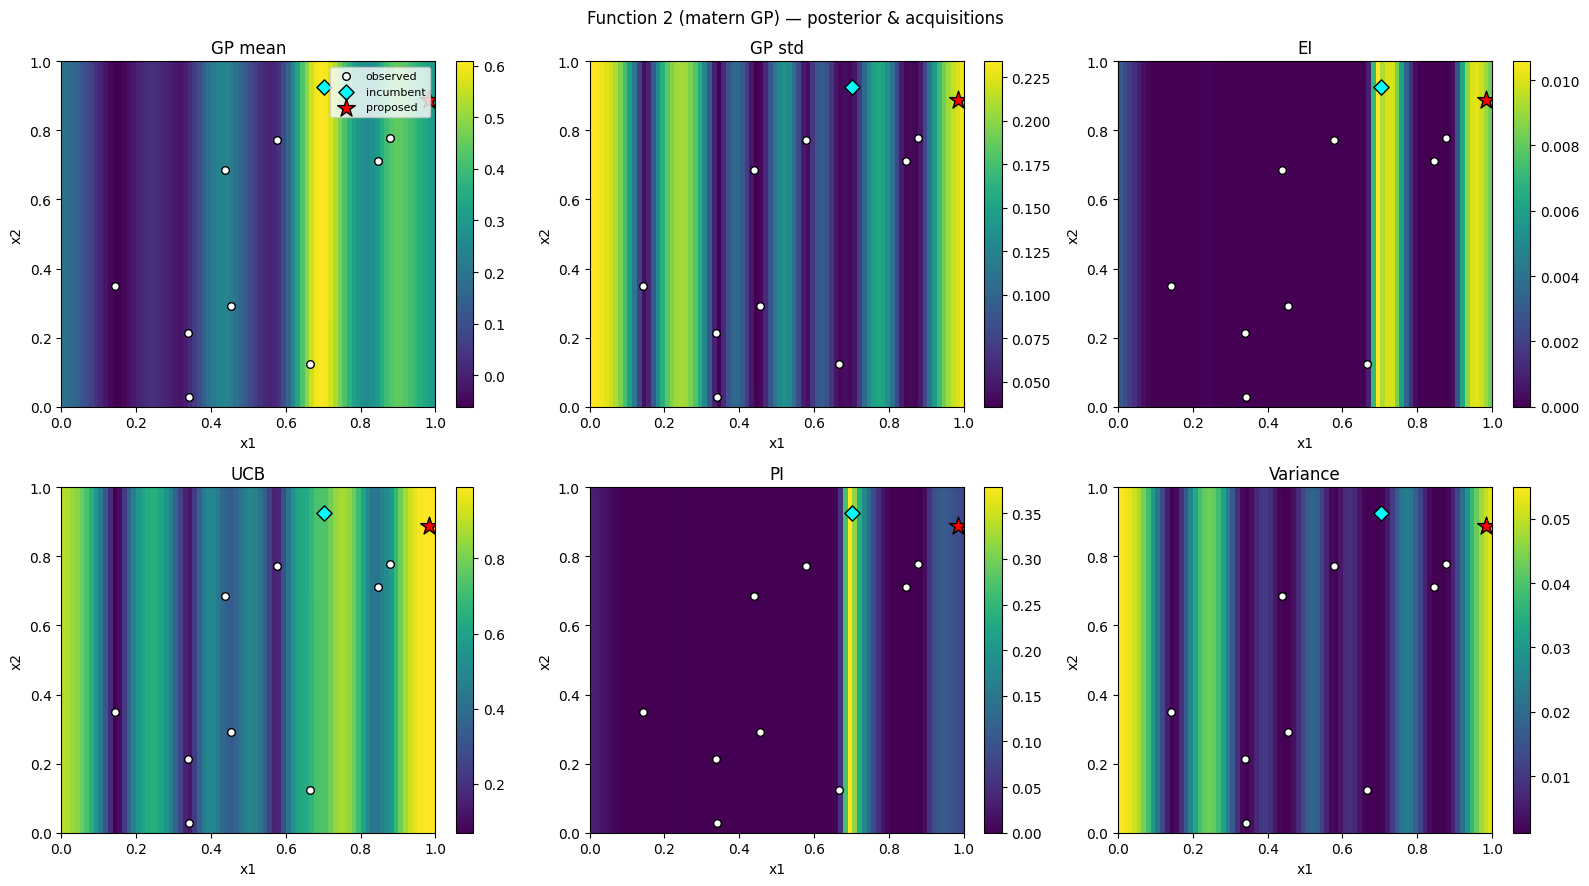

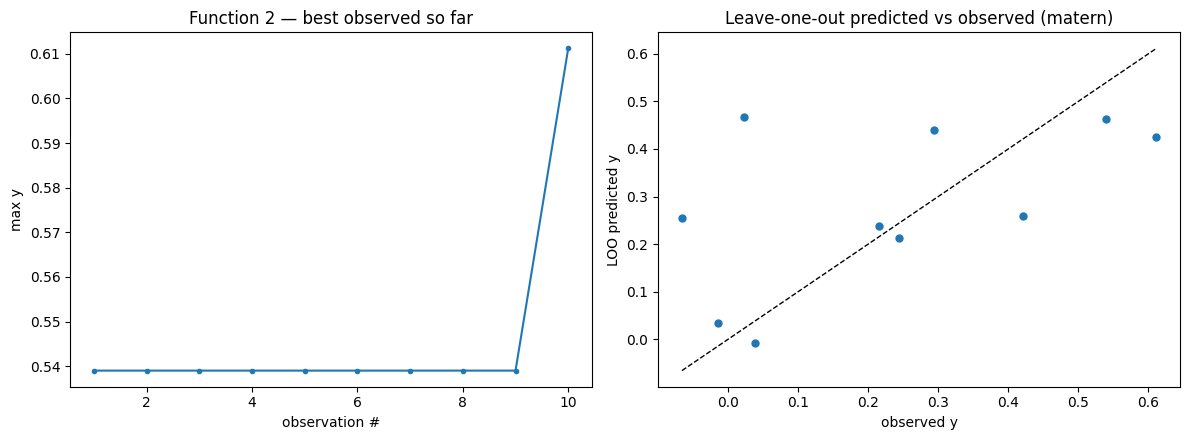

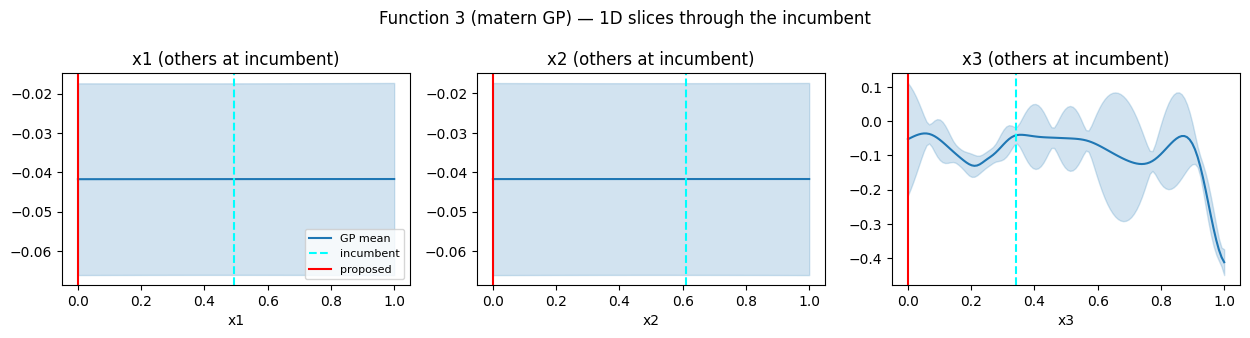

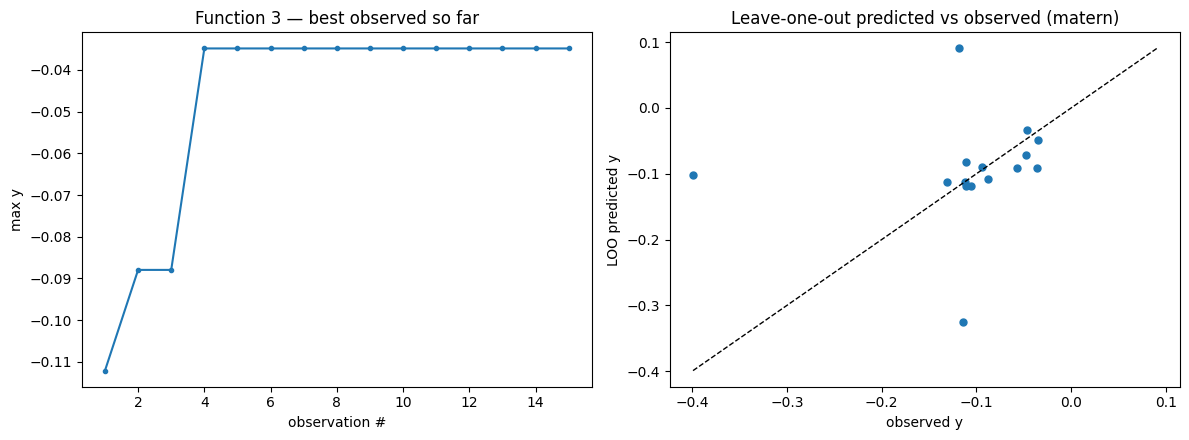

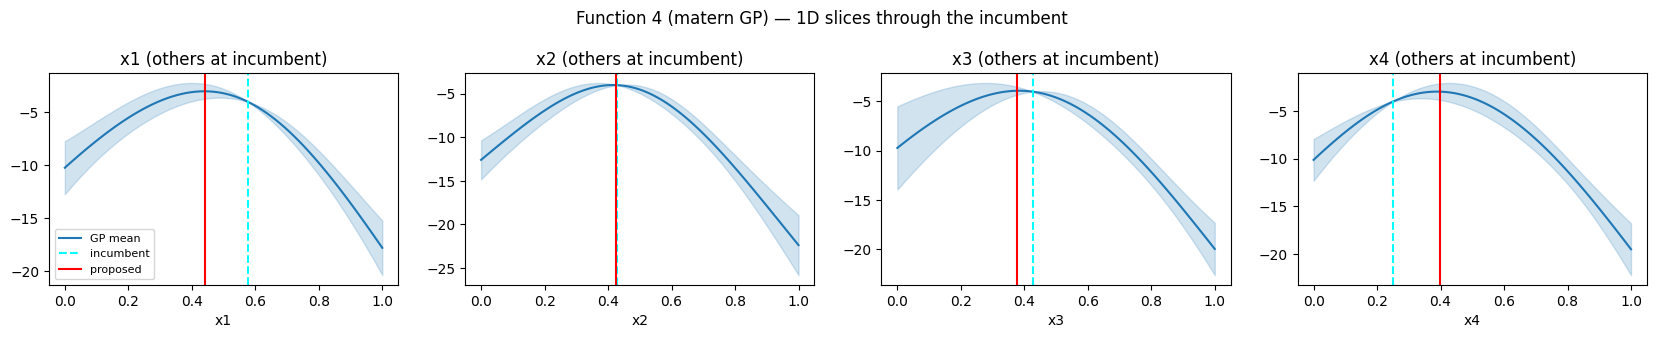

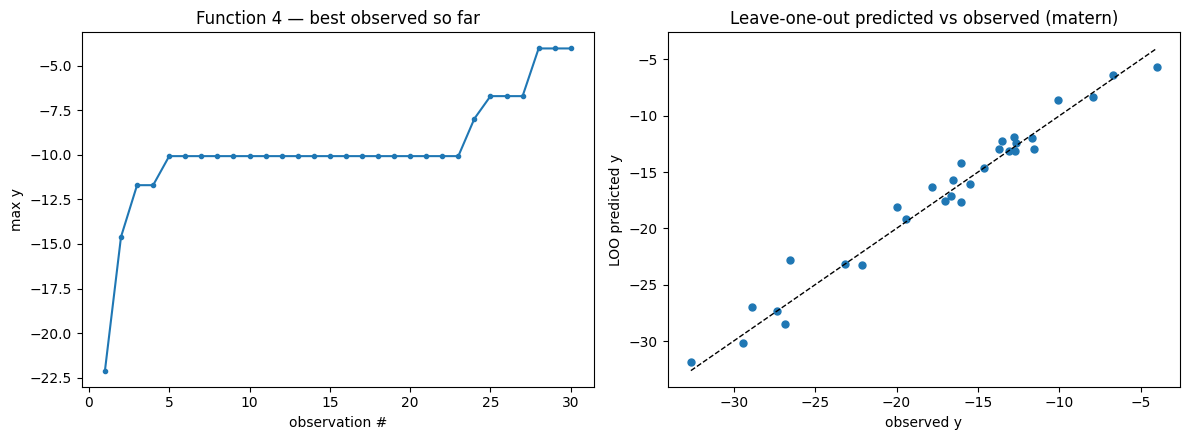

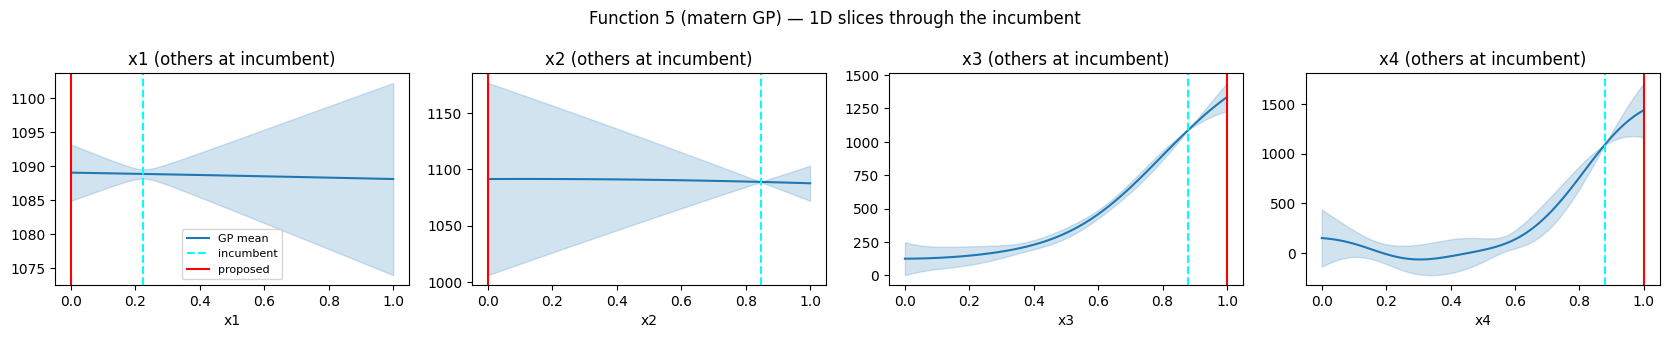

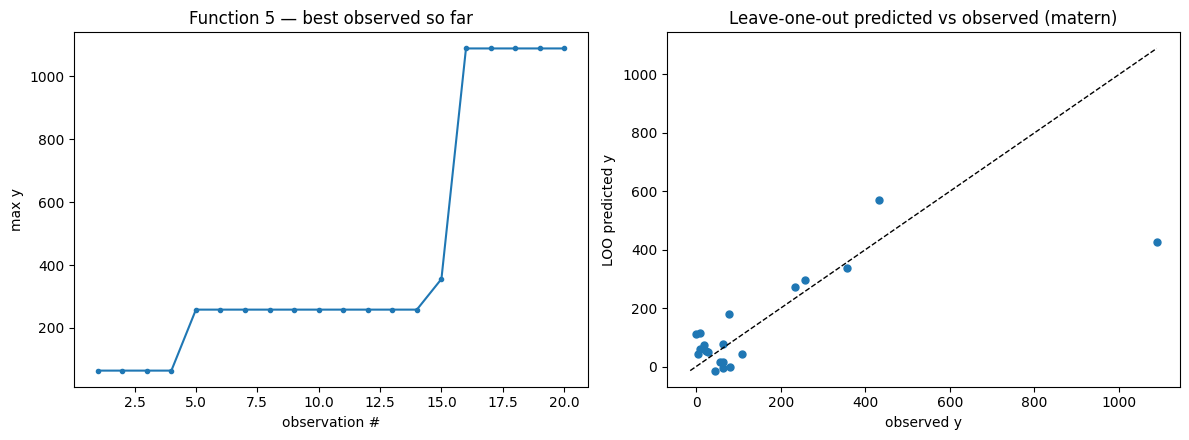

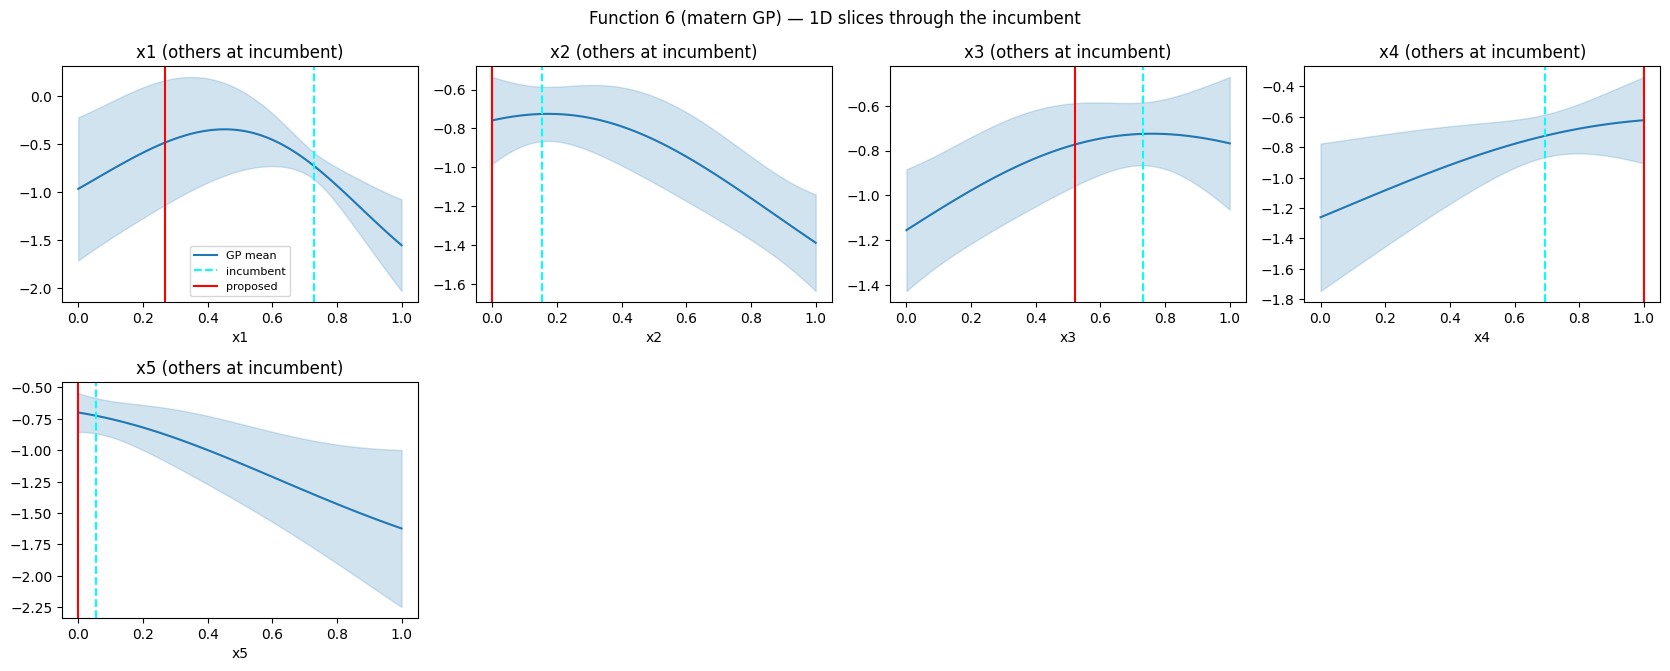

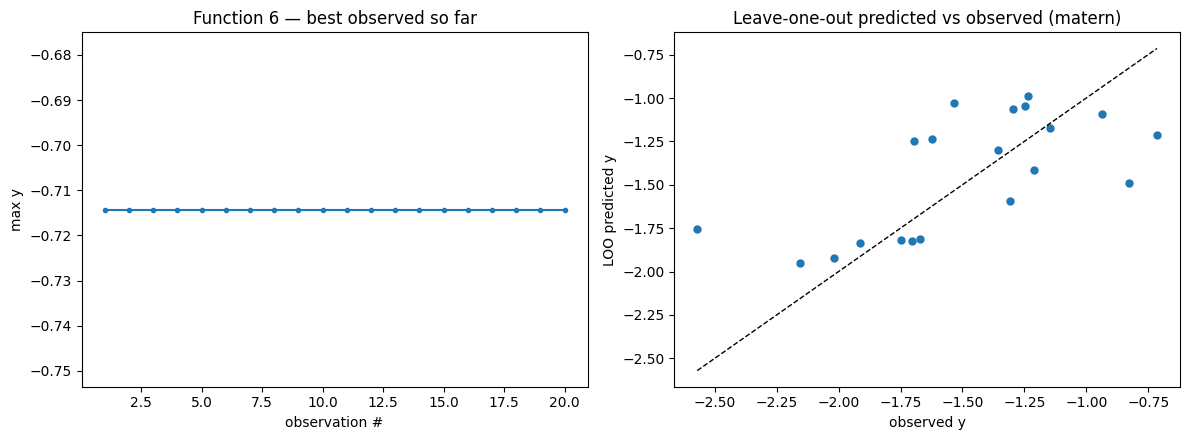

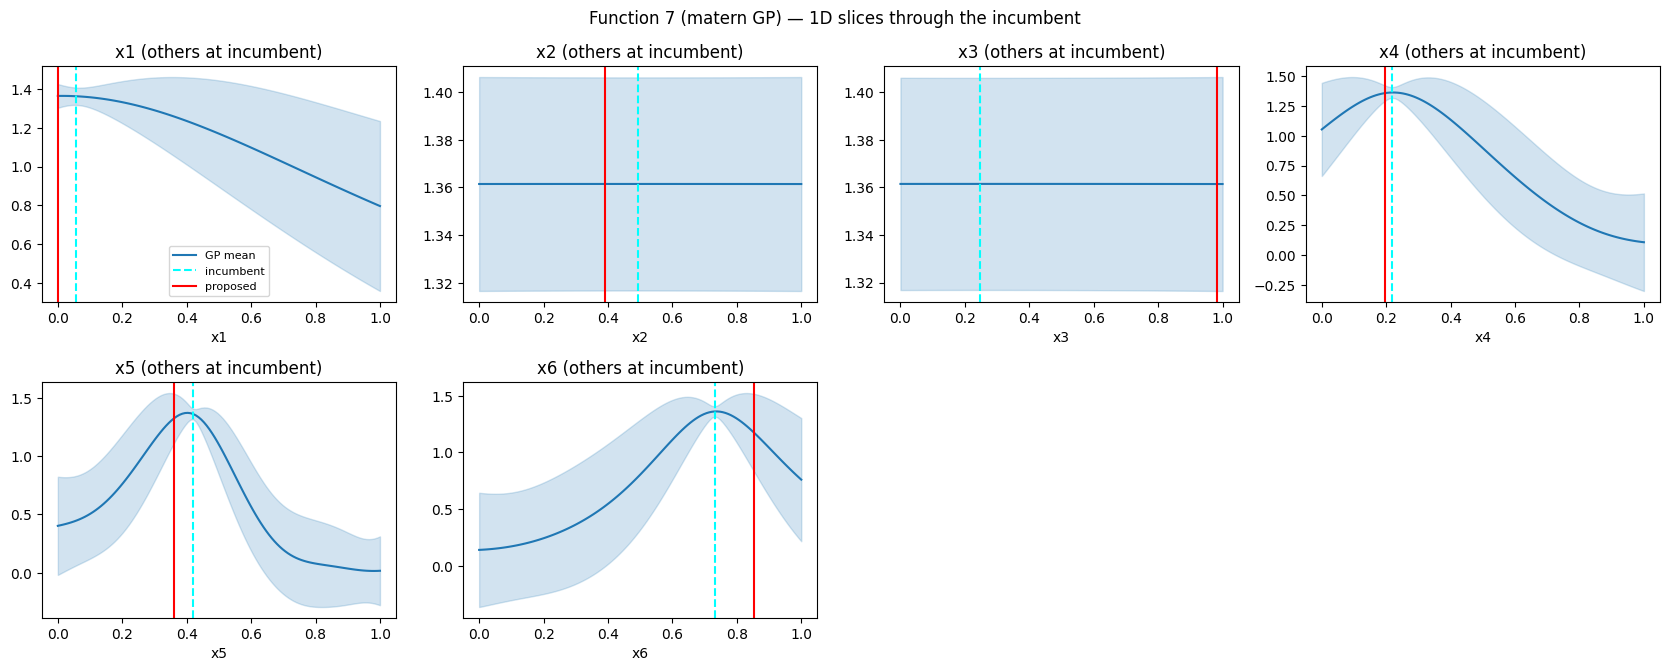

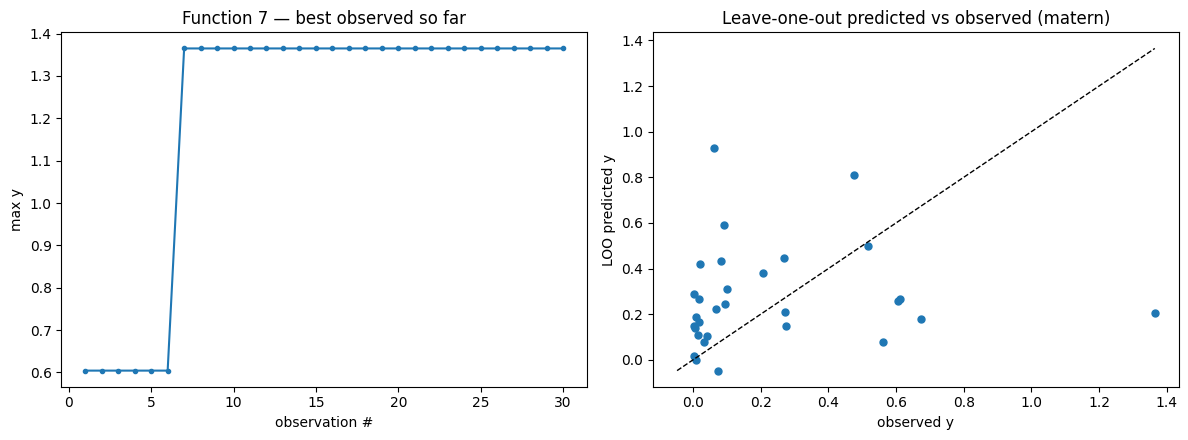

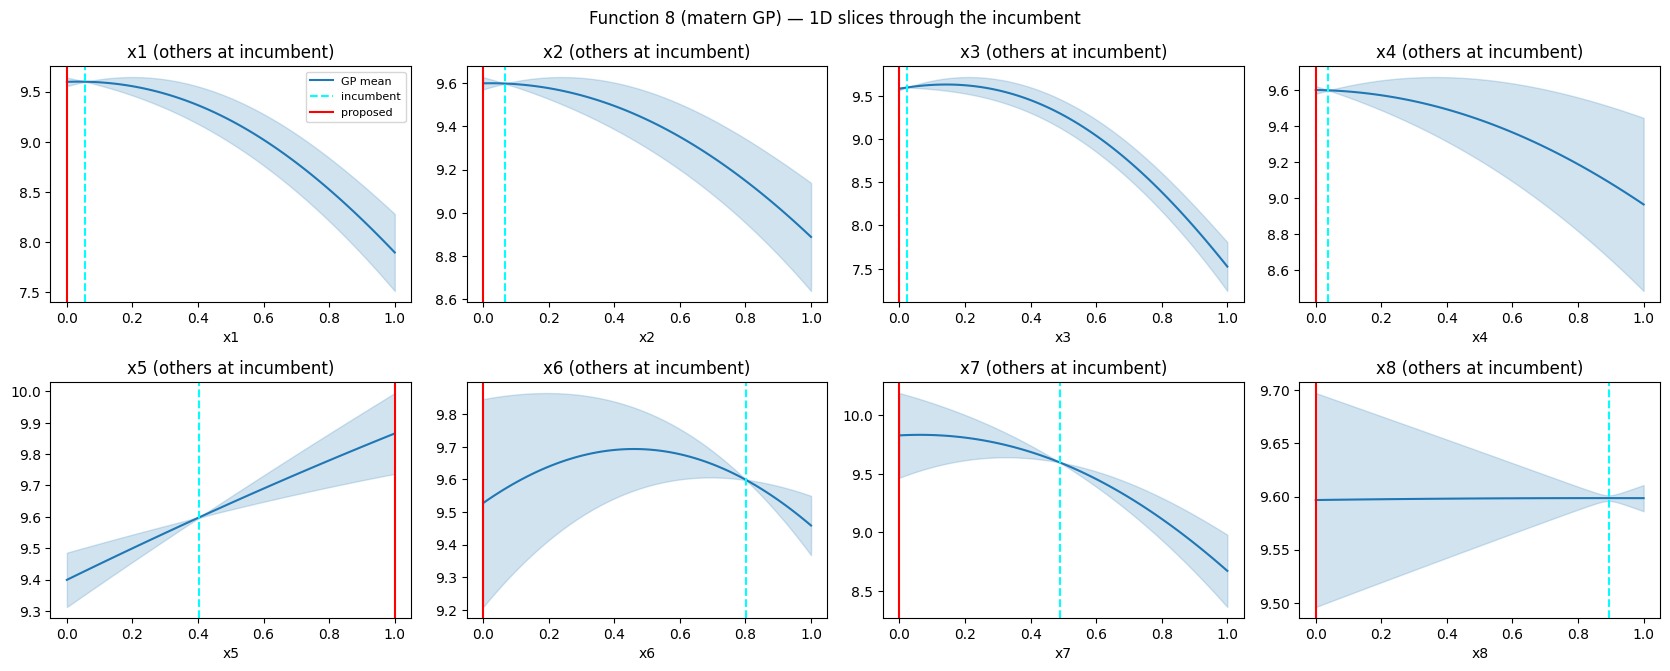

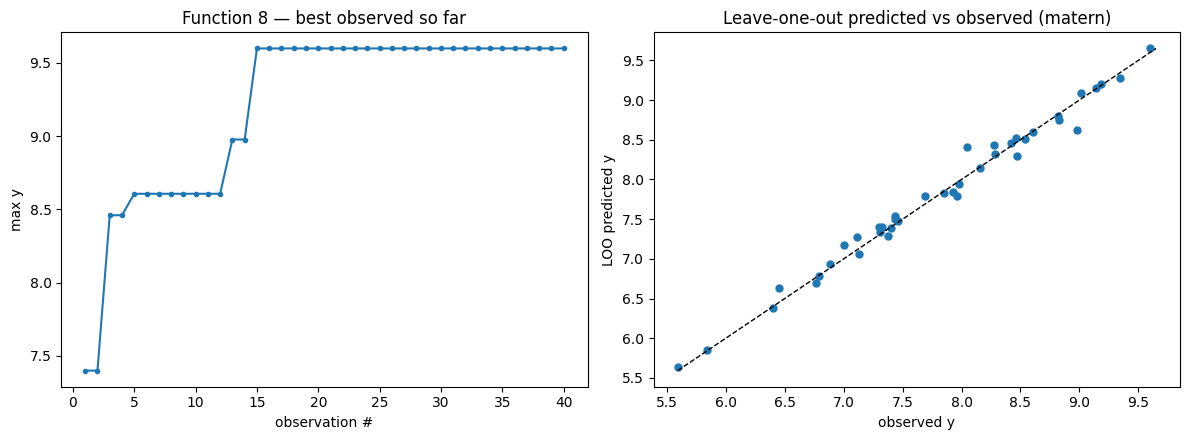

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings — paste these into the portal, one per function


In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.666422-0.206532
f2:  0.983504-0.888870
f3:  0.000000-0.000000-0.000000
f4:  0.440427-0.425455-0.378357-0.397087
f5:  0.000000-0.000000-0.999999-0.999999
f6:  0.268673-0.000000-0.520553-0.999999-0.000000
f7:  0.000000-0.390218-0.982287-0.196815-0.361745-0.852688
f8:  0.000000-0.000000-0.000000-0.000000-0.999999-0.000000-0.000000-0.000000


## 5. Start this week's reflection file

Drops `weekly/reflections/weekNN.md` on disk with a standard intro, the three Part-2
questions to answer, and an auto-filled numbers table. **Won't overwrite** a reflection
I've already written — pass `overwrite=True` to force a fresh scaffold.


In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week01.md


## 6. After the portal returns the scores — record them for next week

Once the portal gives me a score for each submission, fill them in below and run this cell.
Each call to `append_result` adds one row (the input I queried + its score) to that
function's CSV, so the model sees it next round. Then bump `WEEK` and re-run next module.


In [ ]:
# The scores the portal gave back for week 1's submissions.
# Already saved into data/fN.csv outside the notebook — kept here as a record of the round.
# returned_y = {
#     1: 1.0084917708944912e-74,
#     2: 0.052018448907239445,
#     3: -0.17428450654816313,
#     4: 0.2596269993460081,
#     5: 1616.625747348229,
#     6: -0.981584485662507,
#     7: 1.0449229012222199,
#     8: 9.4983001999995,
# }
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
